# 📦Import Libraries

In [28]:
import random
import pandas as pd
import copy
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import ttk, messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from tabulate import tabulate
import math

# 🧬GA Initialization & Core Functions

In [29]:
courses = pd.read_csv("courses.csv").to_dict(orient="records")
lecturers = pd.read_csv("lecturers.csv").to_dict(orient="records")
rooms = pd.read_csv("rooms.csv").to_dict(orient="records")
students = pd.read_csv("students.csv").to_dict(orient="records")
timeslots = pd.read_csv("timeslots.csv").to_dict(orient="records")
students_courses = pd.read_csv("students_courses.csv").to_dict(orient="records")
lecturers_courses = pd.read_csv("lecturers_courses.csv").to_dict(orient="records")

random.seed(42)

def generate_chromosome(courses, rooms, timeslots, students, lecturers):
    all_student_ids = [s['student_id'] for s in students]
    chromosome = []
    
    for course in courses:
        course_id = course.get('course_id')
        if not course_id:
            continue  
            
        if 'students' in course:
            num_students = int(course['students'])
        else:
            num_students = len([sc for sc in students_courses if sc['course_id'] == course_id])
            
        enrolled_students = [sc['student_id'] for sc in students_courses if sc['course_id'] == course_id]

        assigned_students = enrolled_students[:num_students] if len(enrolled_students) >= num_students else enrolled_students

        suitable_rooms = [r for r in rooms]
        room = random.choice(suitable_rooms)

        course_lecturers = [lc['Lecturer ID'] for lc in lecturers_courses if lc['Course ID'] == course_id]
        lecturer_id = random.choice(course_lecturers) if course_lecturers else None

        timeslot = random.choice(timeslots)

        gene = {
            'course_id': str(course_id).strip(),  
            'lecturer_id': str(lecturer_id).strip() if lecturer_id else None,
            'room_id': str(room.get('id')).strip(),
            'students': assigned_students,
            'timeslot_id': int(timeslot.get('timeslot_id'))
        }
        chromosome.append(gene)

    return chromosome

def create_population(population_size, courses, rooms, timeslots, students, lecturers):
    return [generate_chromosome(courses, rooms, timeslots, students, lecturers) for _ in range(population_size)]

PEN_ROOM = 5    
PEN_CLASH = 3.0    
PEN_SPACING = 2.0  

def compute_penalty(chromosome, rooms):
    penalty = 0
    student_ts = {}

    for ex in chromosome:
        cap = next((r.get('capacity', 0) for r in rooms if str(r.get('id')).strip() == str(ex.get('room_id')).strip()), 0)
        n = len(ex.get('students', []))
        if n > cap:
            penalty += PEN_ROOM * 1

        ts = ex.get('timeslot_id', 0)
        student_ts.setdefault(ts, set())
        for sid in ex.get('students', []):
            if sid in student_ts[ts]:
                penalty += PEN_CLASH * 1
            else:
                student_ts[ts].add(sid)

    all_students = {s for e in chromosome for s in e.get('students', [])}
    for sid in all_students:
        times = sorted([e.get('timeslot_id', 0) for e in chromosome if sid in e.get('students', [])])
        for i in range(len(times) - 1):
            if times[i+1] - times[i] == 1:
                penalty += PEN_SPACING

    return penalty

def fitness_function(chromosome, rooms):
    if not chromosome:
        return 0.0
    pen = compute_penalty(chromosome, rooms)
    return 1000.0 / (1.0 + pen)


def tournament_selection(pop, fitness_func, rooms, k=5):
    contenders = random.sample(pop, k)
    contenders.sort(key=lambda c: fitness_func(c, rooms), reverse=True)
    return copy.deepcopy(contenders[0])

def one_point_crossover(parent1, parent2):
    if len(parent1) < 2 or len(parent2) < 2:
        return copy.deepcopy(parent1)
        
    point = random.randint(1, min(len(parent1), len(parent2)) - 1)
    child = parent1[:point] + parent2[point:]
    return child

def uniform_crossover(parent1, parent2):
    child = []
    for g1, g2 in zip(parent1, parent2):
        if random.random() < 0.5:
            child.append(copy.deepcopy(g1))
        else:
            child.append(copy.deepcopy(g2))
    return child

def mutate_room(child, rooms, mutation_rate=0.1):
    child = copy.deepcopy(child)
    for idx in range(len(child)):
        if random.random() < mutation_rate:
            current_room = child[idx].get('room_id')
            new_room = random.choice(rooms)
            while str(new_room.get('id')).strip() == str(current_room).strip():
                new_room = random.choice(rooms)
            child[idx]['room_id'] = str(new_room.get('id')).strip()
    return child

def mutate_timeslot(child, timeslots, mutation_rate=0.1):
    child = copy.deepcopy(child)
    for idx in range(len(child)):
        if random.random() < mutation_rate:
            current_timeslot = child[idx].get('timeslot_id')
            new_timeslot = random.choice(timeslots)
            while new_timeslot.get('timeslot_id') == current_timeslot:
                new_timeslot = random.choice(timeslots)
            child[idx]['timeslot_id'] = new_timeslot.get('timeslot_id', 1)
    return child

def generational_replacement(old_pop, new_pop, fitness_func, rooms):
    combined = new_pop
    combined.sort(key=lambda c: fitness_func(c, rooms), reverse=True)
    return combined[:len(old_pop)]

def elitist_selection(old_pop, new_pop, fitness_func, rooms):
    combined = old_pop + new_pop
    combined.sort(key=lambda c: fitness_func(c, rooms), reverse=True)
    best = copy.deepcopy(combined[0])
    return [best] + combined[1:len(old_pop)]

# 🌐 Diversity & Advanced Selection Methods

In [30]:
def genetic_distance(ind1, ind2):
    if len(ind1) == 0 or len(ind2) == 0 or len(ind1) != len(ind2):
        return 1.0  
    
    total_genes = len(ind1)
    diff_count = 0
    
    for g1, g2 in zip(ind1, ind2):
        room1 = str(g1.get('room_id', '')).strip()
        room2 = str(g2.get('room_id', '')).strip()
        if room1 != room2:
            diff_count += 1
        
        if g1.get('timeslot_id', -1) != g2.get('timeslot_id', -1):
            diff_count += 1
    
    return diff_count / (2 * total_genes)

def shared_fitness(individual, population, rooms, sigma_share=0.3, alpha=1):
    raw_fit = fitness_function(individual, rooms)
    if raw_fit < 1e-6:  
        return 0.0
    
    sharing_sum = 0.0
    pop_size = len(population)
    
    sample_size = min(20, pop_size)  
    sampled_pop = random.sample(population, sample_size) if pop_size > 20 else population
    
    for other in sampled_pop:
        dist = genetic_distance(individual, other)
        if dist < sigma_share:
            sharing_sum += 1 - math.pow(dist / sigma_share, alpha)
    
    if pop_size > 20:
        sharing_sum *= (pop_size / sample_size)
    
    return raw_fit / (sharing_sum if sharing_sum > 1e-6 else 1.0)

def tournament_selection_shared(population, rooms, k=5):
    if len(population) <= k:
        best = max(population, key=lambda ind: shared_fitness(ind, population, rooms))
        return copy.deepcopy(best)
    
    contenders = random.sample(population, k)
    
    fitness_values = [(ind, shared_fitness(ind, population, rooms)) for ind in contenders]
    
    best_individual = max(fitness_values, key=lambda x: x[1])[0]
    return copy.deepcopy(best_individual)

def crowding_replacement(old_population, new_population, fitness_func, rooms):
    new_generation = []
    remaining_old = copy.deepcopy(old_population)
    
    if not remaining_old or not new_population:
        return old_population if not new_population else new_population[:len(old_population)]
    
    for child in new_population:
        if not remaining_old:
            break
            
        closest = min(remaining_old, key=lambda p: genetic_distance(p, child))
        
        if fitness_func(child, rooms) > fitness_func(closest, rooms):
            new_generation.append(copy.deepcopy(child))
        else:
            new_generation.append(copy.deepcopy(closest))
        
        remaining_old.remove(closest)
    
    new_generation.extend(remaining_old[:len(old_population) - len(new_generation)])
    
    return new_generation[:len(old_population)]

# 🚀 Co-Evolution Strategy for Exam Timetabling

In [31]:
def co_evolution (
    generations,
    population_size,
    courses,
    rooms,
    timeslots,
    students,
    lecturers,
    students_courses,
    lecturers_courses,
    crossover_func,
    mutation_func,
    survivor_func
):
    population = create_population(population_size, courses, rooms, timeslots, students, lecturers)

    best_solution = None
    best_fitness = 0

    for gen in range(generations):
        new_population = []

        for _ in range(population_size):
            parent1 = tournament_selection(population, fitness_function, rooms)
            parent2 = tournament_selection(population, fitness_function, rooms)

            child = crossover_func(parent1, parent2)

            if mutation_func == mutate_room:
                child = mutation_func(child, rooms)
            else:
                child = mutation_func(child, timeslots)

            new_population.append(child)

        population = survivor_func(population, new_population, fitness_function, rooms)

        for chromo in population:
            fit = fitness_function(chromo, rooms)
            if fit > best_fitness:
                best_fitness = fit
                best_solution = chromo

        print(f"Co-Evolution Generation {gen + 1}: Best Fitness = {best_fitness:.4f}")

    return best_solution

# ⚙️ Run Evolution with Strategy Comparison

In [32]:
def run_evolution_with_comparison(population_size, generations, recombination_methods, mutation_methods, survivor_methods):
    results = {}
    gen_fitness_log = {}

    print(f"\nStarting EA with {generations} generations...\n")

    for recomb_name, recomb_func in recombination_methods.items():
        for mut_name, mut_func in mutation_methods.items():
            for surv_name, surv_func in survivor_methods.items():

                key = f"{recomb_name}_{mut_name}_{surv_name}"
                print(f"Running: {key}")

                pop = create_population(population_size, courses, rooms, timeslots, students, lecturers)

                best_fitnesses = []
                for gen in range(generations):
                    offspring = []

                    while len(offspring) < population_size:
                        if surv_name == "Crowding":
                            p1 = tournament_selection_shared(pop, rooms)
                            p2 = tournament_selection_shared(pop, rooms)
                        else:
                            p1 = tournament_selection(pop, fitness_function, rooms)
                            p2 = tournament_selection(pop, fitness_function, rooms)

                        child1 = recomb_func(copy.deepcopy(p1), copy.deepcopy(p2))
                        child2 = recomb_func(copy.deepcopy(p2), copy.deepcopy(p1))
                        child1 = mut_func(copy.deepcopy(child1), rooms)
                        child2 = mut_func(copy.deepcopy(child2), rooms)
                        offspring.extend([child1, child2])

                    pop = surv_func(pop, offspring, fitness_function, rooms)

                    best = max(pop, key=lambda ind: fitness_function(ind, rooms))
                    best_fitness = fitness_function(best, rooms)
                    best_fitnesses.append(best_fitness)

                results[key] = best_fitnesses[-1]
                gen_fitness_log[key] = best_fitnesses
                print(f"Final Best Fitness: {best_fitness:.4f}")

    return results, gen_fitness_log

recombination_methods = {
    "OnePoint": one_point_crossover,
    "Uniform": uniform_crossover
}

mutation_methods = {
    "RoomMut": mutate_room,
    "TimeMut": mutate_timeslot
}

survivor_methods = {
    "Generational": generational_replacement,
    "Elitism": elitist_selection,
    "Crowding": crowding_replacement
}

# 🖥️ Tkinter GUI for Generating and Visualizing Timetables


Starting EA with 5 generations...

Running: OnePoint_RoomMut_Generational
Final Best Fitness: 0.8354
Running: OnePoint_RoomMut_Elitism
Final Best Fitness: 0.7981
Running: OnePoint_RoomMut_Crowding
Final Best Fitness: 0.8628
Running: OnePoint_TimeMut_Generational
Final Best Fitness: 0.5970
Running: OnePoint_TimeMut_Elitism
Final Best Fitness: 0.8905
Running: OnePoint_TimeMut_Crowding
Final Best Fitness: 0.9653
Running: Uniform_RoomMut_Generational
Final Best Fitness: 0.9251
Running: Uniform_RoomMut_Elitism
Final Best Fitness: 0.9372
Running: Uniform_RoomMut_Crowding
Final Best Fitness: 0.9662
Running: Uniform_TimeMut_Generational
Final Best Fitness: 0.4179
Running: Uniform_TimeMut_Elitism
Final Best Fitness: 0.8554
Running: Uniform_TimeMut_Crowding
Final Best Fitness: 0.9158
Generation 1: Best Fitness = 1.0070
Generation 2: Best Fitness = 1.0173
Generation 3: Best Fitness = 1.0225
Generation 4: Best Fitness = 1.0331
Generation 5: Best Fitness = 1.0384


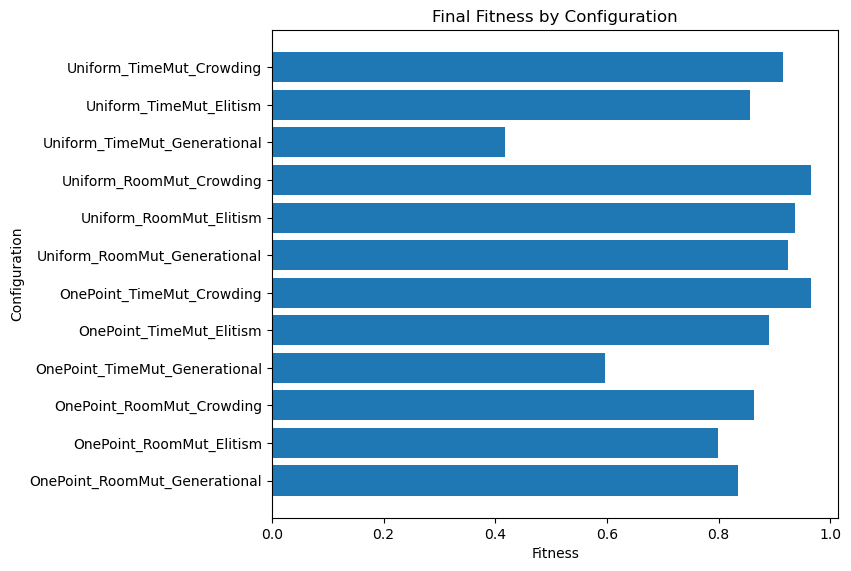

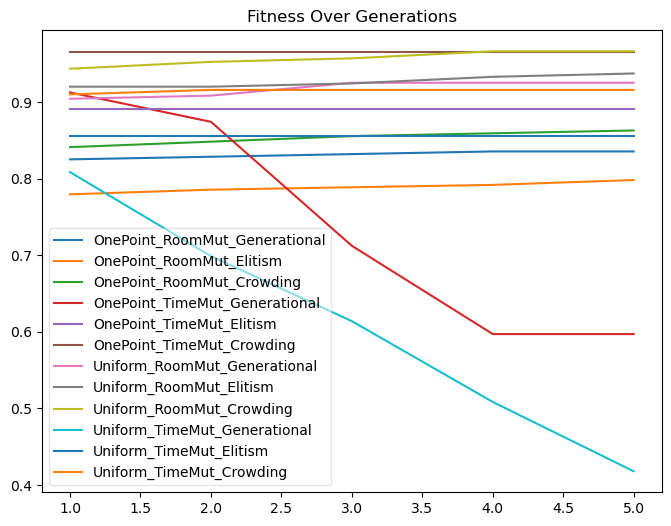

In [33]:
class TimetableApp(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Exam Timetable Generator")
        self.state("zoomed")  
        self.selected_courses = []
        self.best_schedule = None
        self.fitness_log = {}
        self.course_vars = []

        self.create_widgets()

    def create_widgets(self):
        main_frame = tk.Frame(self)
        main_frame.pack(fill="both", expand=True)

        tk.Label(main_frame, text="Select Courses:", font=("Arial", 14)).pack(pady=10)

        frame_container = tk.Frame(main_frame)
        frame_container.pack(pady=5, fill='both', expand=True)

        canvas = tk.Canvas(frame_container, height=200)
        scrollbar = ttk.Scrollbar(frame_container, orient="vertical", command=canvas.yview)
        scrollable_frame = tk.Frame(canvas)

        scrollable_frame.bind("<Configure>", lambda e: canvas.configure(scrollregion=canvas.bbox("all")))
        canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")
        canvas.configure(yscrollcommand=scrollbar.set)

        canvas.pack(side="left", fill="both", expand=True)
        scrollbar.pack(side="right", fill="y")

        for course in courses:
            var = tk.BooleanVar()
            chk = tk.Checkbutton(scrollable_frame, text=f"{course['course_id']} - {course['course_name']}", variable=var, anchor='w')
            chk.pack(fill='x', padx=5)
            self.course_vars.append((var, course['course_id']))

        control_frame = tk.Frame(main_frame)
        control_frame.pack(pady=10)

        self.select_all_btn = tk.Button(control_frame, text="Select All", command=self.select_all_courses, font=("Arial", 12), height=2, width=17,
                                        bg="blue", fg="white")
        self.select_all_btn.pack(side='left', padx=10)

        tk.Button(control_frame, text="Generate Time Table", command=self.generate_schedule,
                  bg="green", fg="white", font=("Arial", 12), height=2, width=17).pack(side='left')

    def select_all_courses(self):
        for var, _ in self.course_vars:
            var.set(True)

    def generate_schedule(self):
        selected_ids = [cid for var, cid in self.course_vars if var.get()]
        if not selected_ids:
            messagebox.showerror("Error", "Please select at least one course.")
            return
    
        selected_courses = [c for c in courses if c['course_id'] in selected_ids]
    
        population_size = 5
        generations = 5
    
        _, gen_fitness_log = run_evolution_with_comparison(
            population_size=population_size,
            generations=generations,
            recombination_methods=recombination_methods,
            mutation_methods=mutation_methods,
            survivor_methods=survivor_methods
        )
    
        self.fitness_log = gen_fitness_log
        best_config = max(self.fitness_log.items(), key=lambda x: x[1][-1] if len(x[1]) > 0 else float('-inf'))[0]
        self.best_config = best_config
        recomb_name, mut_name, surv_name = best_config.split('_')
        recomb_func = recombination_methods[recomb_name]
        mut_func = mutation_methods[mut_name]
        surv_func = survivor_methods[surv_name]
    
        best_pop = create_population(population_size, selected_courses, rooms, timeslots, students, lecturers)
        for _ in range(generations):  
            offspring = []
            while len(offspring) < population_size:
                p1 = tournament_selection(best_pop, fitness_function, rooms)
                p2 = tournament_selection(best_pop, fitness_function, rooms)
                child1 = recomb_func(copy.deepcopy(p1), copy.deepcopy(p2))
                child2 = recomb_func(copy.deepcopy(p2), copy.deepcopy(p1))
                child1 = mut_func(child1, rooms)
                child2 = mut_func(child2, rooms)
                offspring.extend([child1, child2])
            best_pop = surv_func(best_pop, offspring, fitness_function, rooms)
    
        best_chromosome_normal = max(best_pop, key=lambda c: fitness_function(c, rooms))
    
        best_chromosome_coevo = co_evolution(
            generations=generations,
            population_size=population_size,
            courses=selected_courses,
            rooms=rooms,
            timeslots=timeslots,
            students=students,
            lecturers=lecturers,
            students_courses=students_courses,
            lecturers_courses=lecturers_courses,
            crossover_func=recomb_func,
            mutation_func=mut_func,
            survivor_func=surv_func
        )
    
        self.show_best_timetable(best_chromosome_normal, "Best Timetable (Traditional Evolution)")
        self.show_best_timetable(best_chromosome_coevo, "Best Timetable (Co-Evolution)")
    
        self.show_bar_plot()
        self.show_line_plot()
        self.show_summary()

    def show_best_timetable(self, schedule, title):
        new_window = tk.Toplevel(self)
        new_window.title(title)
        new_window.geometry("900x600")

        df_final = pd.DataFrame(schedule)
        
        df_final['course_id'] = df_final['course_id'].astype(str).str.strip()  
        courses_df = pd.DataFrame(courses)
        courses_df['course_id'] = courses_df['course_id'].astype(str).str.strip()  
    
        df_final = df_final.merge(
            courses_df[['course_id', 'course_name', 'students', 'hours']],
            on='course_id', how='left'
        )
    
        lecturers_courses_df = pd.DataFrame(lecturers_courses)
        lecturers_courses_df['Course ID'] = lecturers_courses_df['Course ID'].astype(str).str.strip()
        
        lecturers_per_course = lecturers_courses_df.groupby('Course ID')['Lecturer ID'].agg(list).reset_index()
        
        lecturers_df = pd.DataFrame(lecturers)
        lecturers_df['Lecturer ID'] = lecturers_df['Lecturer ID'].astype(str).str.strip()
        
        def get_lecturer_names(lecturer_ids):
            names = []
            for lid in lecturer_ids:
                lecturer_name = lecturers_df.loc[lecturers_df['Lecturer ID'] == lid, 'Lecturer Name'].values
                if len(lecturer_name) > 0:
                    names.append(lecturer_name[0])
            return ', '.join(names) if names else None
        
        lecturers_per_course['Lecturer Names'] = lecturers_per_course['Lecturer ID'].apply(get_lecturer_names)
        
        df_final = df_final.merge(
            lecturers_per_course[['Course ID', 'Lecturer Names']],
            left_on='course_id', right_on='Course ID', how='left'
        )
    
        rooms_df = pd.DataFrame(rooms)
        rooms_df['id'] = rooms_df['id'].astype(str).str.strip()  
        df_final = df_final.merge(
            rooms_df[['id', 'capacity']],
            left_on='room_id', right_on='id', how='left',
            suffixes=('', '_room')
        )
    
        timeslots_df = pd.DataFrame(timeslots).rename(columns={'timeslot_id': 'timeslot_id'})
        df_final = df_final.merge(timeslots_df, on='timeslot_id', how='left')
    
        df_final = df_final.drop(columns=['id', 'Course ID', 'Lecturer ID', 'id_room'], errors='ignore')
    
        df_display = df_final.rename(columns={
            'course_id': 'Course ID',
            'course_name': 'Course Name',
            'Lecturer Names': 'Lecturer Name',
            'room_id': 'Room Name',
            'capacity': 'Room Capacity',
            'day': 'Day',
            'time': 'Time',
            'students_y': 'Number Of Students'
        })
    
        df_display = df_display[[
            'Day', 'Time', 'Course ID', 'Course Name',
            'Lecturer Name', 'Room Name', 'Room Capacity',
            'Number Of Students'
        ]]
    
        day_order = {'Sunday': 0, 'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4}
        df_display['day_order'] = df_display['Day'].map(day_order)
        df_display = df_display.sort_values(by=['day_order', 'Time'])
        df_display = df_display.drop(columns=['day_order'])
    
        if "Co-Evolution" not in title:
            tk.Label(new_window, text=f"Best Config: {self.best_config}", font=("Arial", 12, "bold")).pack(pady=10)
        else:
            tk.Label(new_window, text=title, font=("Arial", 12, "bold")).pack(pady=10)

    
        text_frame = tk.Frame(new_window)
        text_frame.pack(fill='both', expand=True)
    
        txt = tk.Text(text_frame, wrap=tk.NONE, font=("Courier", 10))
        txt.insert(tk.END, tabulate(df_display, headers='keys', tablefmt='fancy_grid', showindex=True))
        txt.pack(side=tk.LEFT, fill='both', expand=True)
    
        scroll_y = tk.Scrollbar(text_frame, orient="vertical", command=txt.yview)
        scroll_y.pack(side=tk.RIGHT, fill='y')
        txt.configure(yscrollcommand=scroll_y.set)
    
        scroll_x = tk.Scrollbar(new_window, orient="horizontal", command=txt.xview)
        scroll_x.pack(fill='x')
        txt.configure(xscrollcommand=scroll_x.set)


    def show_bar_plot(self):
        new_window = tk.Toplevel(self)
        new_window.title("Bar Plot")
        new_window.geometry("800x600")
    
        fig, ax = plt.subplots(figsize=(10, 5))
        keys = list(self.fitness_log.keys())
        bar_vals = [v[-1] for v in self.fitness_log.values()]
    
        ax.barh(keys, bar_vals)  
        ax.set_title("Final Fitness by Configuration")
        ax.set_xlabel("Fitness")  
        ax.set_ylabel("Configuration")  
    
        fig.tight_layout()  
    
        canvas = FigureCanvasTkAgg(fig, master=new_window)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=1, fill='both')


    def show_line_plot(self):
        new_window = tk.Toplevel(self)
        new_window.title("Line Plot")
        new_window.geometry("800x600")

        fig, ax = plt.subplots(figsize=(10, 5))
        for k, vals in self.fitness_log.items():
            ax.plot(range(1, len(vals) + 1), vals, label=k)
        ax.set_title("Fitness Over Generations")
        legend = ax.legend(framealpha=0.5)  

        canvas = FigureCanvasTkAgg(fig, master=new_window)
        canvas.draw()
        canvas.get_tk_widget().pack(expand=1, fill='both')

    def show_summary(self):
        new_window = tk.Toplevel(self)
        new_window.title("Top Fitness (Every 10 Gen)")
        new_window.geometry("800x600")
    
        tk.Label(new_window, text="Top Fitness Every 10 Generations", font=("Arial", 14, "bold"), fg="darkgreen").pack(pady=10)
    
        text_frame = tk.Frame(new_window)
        text_frame.pack(expand=1, fill='both')
    
        summary_txt = tk.Text(text_frame, wrap=tk.WORD, font=("Consolas", 10), padx=10, pady=10, bg="#f9f9f9")
        summary_txt.pack(side=tk.LEFT, expand=1, fill='both')
    
        scroll_y = tk.Scrollbar(text_frame, orient="vertical", command=summary_txt.yview)
        scroll_y.pack(side=tk.RIGHT, fill='y')
        summary_txt.configure(yscrollcommand=scroll_y.set)
    
        summary_txt.insert(tk.END, "Configuration-wise Top Fitness per 10 Generations:\n\n")
    
        for key, values in self.fitness_log.items():
            top10s = [max(values[i:i+10]) for i in range(0, len(values), 10)]
            summary_txt.insert(tk.END, f"{key}\n")
            for idx, val in enumerate(top10s):
                summary_txt.insert(tk.END, f"  Gen {idx*10+1:02d}-{(idx+1)*10:02d}: {val:.4f}\n")
            summary_txt.insert(tk.END, "\n" + "-"*60 + "\n\n")
        summary_txt.configure(state="disabled")  

if __name__ == "__main__":
    app = TimetableApp()
    app.mainloop()